# Libraries

In [1]:
import pandas as pd
import numpy as np
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# International Tourism - Results by Year

In [2]:
df_dashboard = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\1. Data\Tourism Results (UNTWO Dashboard).xlsx", sheet_name='global')

In [3]:
df_dashboard

,Year,Arrivals (in millions),Receipts (USD billion)
0,2016,1246.0,1245.0
1,2017,1338.0,1346.0
2,2018,1415.0,1457.0
3,2019,1466.0,1487.0
4,2020,407.9,557.9
5,2021,461.4,655.4
6,2022,975.6,1142.0
7,2023,1306.0,1536.0
8,2024,1465.0,1731.0


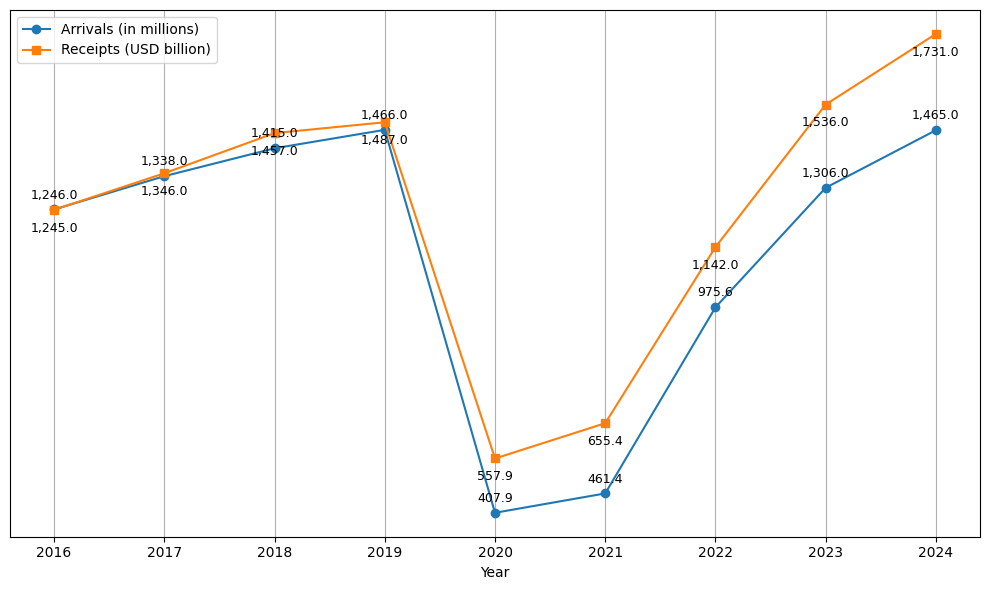

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(df_dashboard['Year'], df_dashboard['Arrivals (in millions)'], marker='o', label='Arrivals (in millions)')
plt.plot(df_dashboard['Year'], df_dashboard['Receipts (USD billion)'], marker='s', label='Receipts (USD billion)')

#plt.title('International Tourist Arrivals & Tourism Receipts (2016–2024)', fontweight='bold')

plt.xlabel('Year')
plt.ylabel('')

plt.yticks([])

for i, year in enumerate(df_dashboard['Year']):
    plt.text(year, df_dashboard['Arrivals (in millions)'][i] + 30,  # posición y ajustada
             f"{df_dashboard['Arrivals (in millions)'][i]:,.1f}", ha='center', fontsize=9)
    
    plt.text(year, df_dashboard['Receipts (USD billion)'][i] - 60,  # posición y ajustada
             f"{df_dashboard['Receipts (USD billion)'][i]:,.1f}", ha='center', fontsize=9)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# International Tourism - Variation 2024 vs 2019

In [5]:
df_dash_region = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\1. Data\Tourism Results (UNTWO Dashboard).xlsx", sheet_name='region')

In [6]:
for col in ["Arrivals", "Receipts"]:
    df_dash_region[col] = pd.to_numeric(
        df_dash_region[col].astype(str).str.replace('%', ''), errors='coerce'
    )

In [7]:
df_dash_region.style

,Region,Arrivals,Receipts
0,World,0.999318,1.164089
1,Middle East,1.413408,1.634551
2,Africa,1.074128,1.078481
3,Europe,1.015862,1.238982
4,Americas,0.987688,1.187009
5,Asia & Pacific,0.876830,0.958522


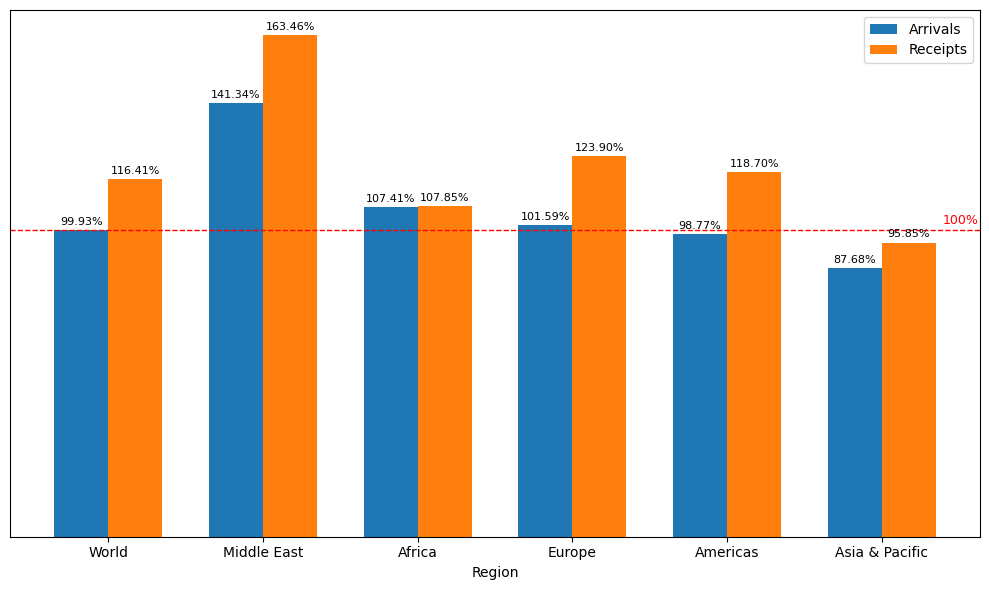

In [8]:
plt.figure(figsize=(10, 6))

x = df_dash_region["Region"]
arrivals = df_dash_region["Arrivals"] * 100
receipts = df_dash_region["Receipts"] * 100

bar_width = 0.35
index = range(len(x))

bars1 = plt.bar(index, arrivals, bar_width, label="Arrivals")
bars2 = plt.bar([i + bar_width for i in index], receipts, bar_width, label="Receipts")

plt.axhline(y=100, color='red', linestyle='--', linewidth=1)
plt.text(len(df_dash_region) - 0.2, 102, "100%", color='red', fontsize=9, ha='right')

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontsize = 8)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontsize = 8)

plt.xlabel("Region")
plt.xticks([i + bar_width / 2 for i in index], x)
#plt.title("Tourism Recovery by Region: Arrivals and Receipts 2024 vs 2019", fontweight='bold')
plt.legend()
plt.gca().axes.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

# International Results 2024 - Europe's Lead

In [9]:
df_avg = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\1. Data\Tourism Results (UNTWO Dashboard).xlsx", sheet_name='region_absolut')

In [10]:
df_avg

,Region,Arrivals (in millions),Receipts (in billions),Avg. Per Tourist
0,World,1465.0,1731.0,1181.569966
1,Middle East,101.2,147.6,1458.498024
2,Africa,73.9,42.6,576.454668
3,Europe,755.7,725.3,959.772396
4,Americas,216.6,392.9,1813.942752
5,Asia & Pacific,317.5,422.9,1331.968504


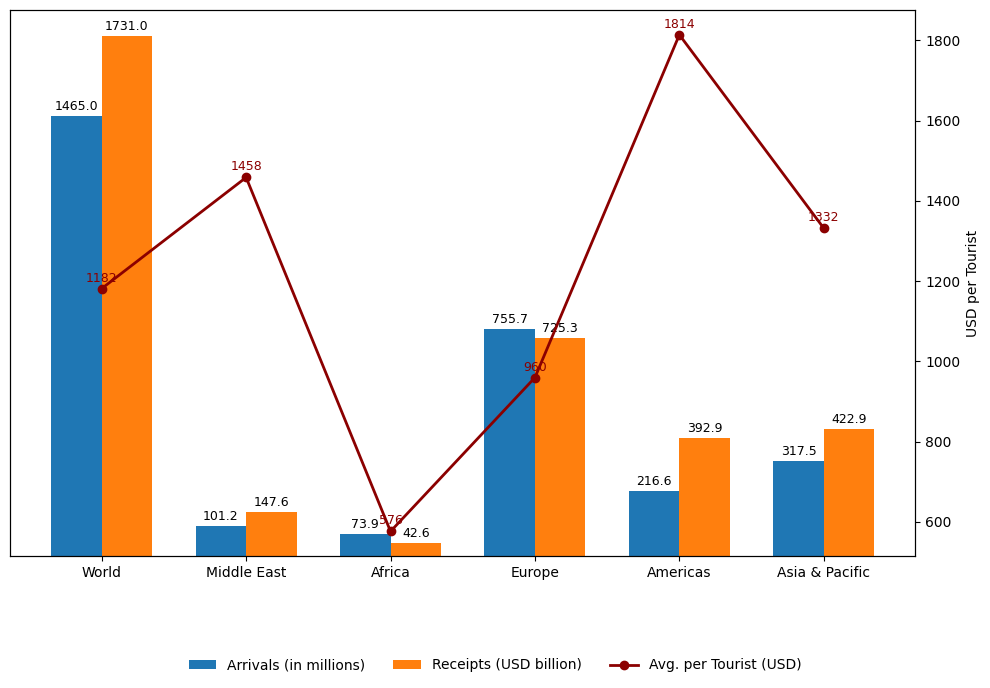

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6))
bar_width = 0.35
x = range(len(df_avg))

bars1 = ax1.bar([i - bar_width/2 for i in x], df_avg['Arrivals (in millions)'],
                width=bar_width, label='Arrivals (in millions)')
bars2 = ax1.bar([i + bar_width/2 for i in x], df_avg['Receipts (in billions)'],
                width=bar_width, label='Receipts (USD billion)')

#ax1.set_ylabel('Millions / Billions')
plt.yticks([])
#ax1.set_title('Tourism by Region (2024): Arrivals, Receipts, and Avg. Spend per Tourist', fontweight='bold')
ax1.set_xticks(list(x))
ax1.set_xticklabels(df_avg['Region'])

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 10, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 10, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax2 = ax1.twinx()
line = ax2.plot(x, df_avg['Avg. Per Tourist'], label='Avg. per Tourist (USD)', color='darkred', marker='o', linewidth=2)
ax2.set_ylabel('USD per Tourist')

for i, val in enumerate(df_avg['Avg. Per Tourist']):
    ax2.text(i, val + 10, f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='darkred')

lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
handles, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

# Ranking of Countries

In [12]:
df_countries_rank = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\1. Data\Tourism Results (UNTWO Dashboard).xlsx", sheet_name='countries')

df_countries_rank.columns = df_countries_rank.columns.astype(str)

df_countries_rank = df_countries_rank[['Country', '2019', '2024']]

df_countries_rank['Change'] = df_countries_rank['2024'] - df_countries_rank['2019']

c:\Users\franc\Documents\GitHub\DSE_thesis\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [13]:
df_countries_rank

,Country,2019,2024,Change
0,France,90.9,102.0,11.1
1,Spain,83.5,93.8,10.3
2,United States,79.4,72.4,-7.0
3,China,65.7,32.0,-33.7
4,Italy,64.5,57.8,-6.7
5,Türkiye,51.2,60.6,9.4
6,Mexico,45.0,45.0,0.0
7,Thailand,39.9,35.5,-4.4
8,Germany,39.6,37.5,-2.1
9,UK,39.4,41.2,1.8


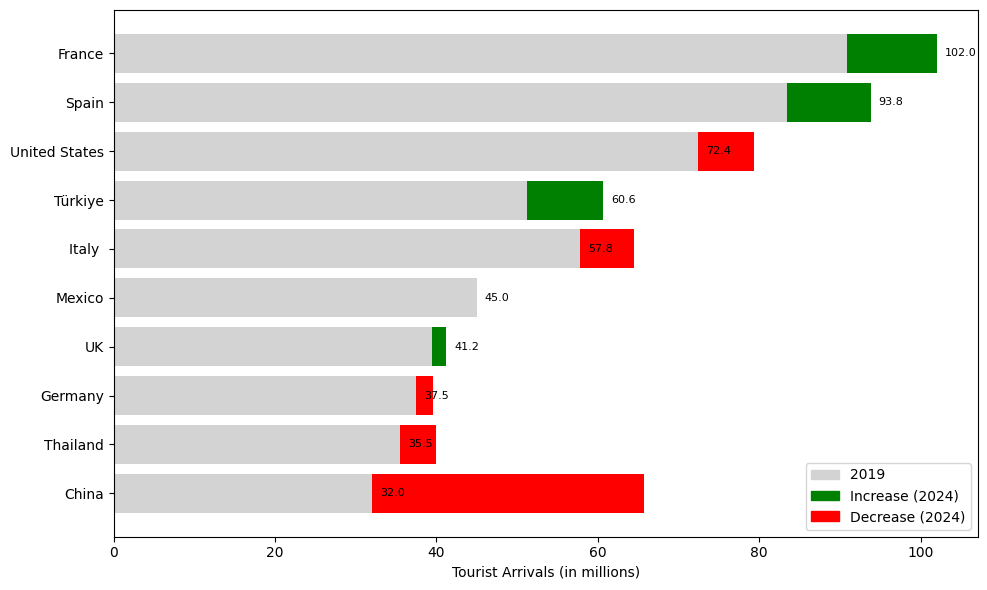

In [14]:
df_countries_rank.columns = df_countries_rank.columns.astype(str)

df_countries_rank['Change'] = df_countries_rank['2024'] - df_countries_rank['2019']

df_countries_rank.sort_values('2024', ascending=True, inplace=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df_countries_rank['Country'], df_countries_rank['2019'], color='lightgray', label='2019')

ax.barh(
    df_countries_rank['Country'],
    df_countries_rank['Change'],
    left=df_countries_rank['2019'],
    color=df_countries_rank['Change'].apply(lambda x: 'green' if x > 0 else 'red'),
    label='Change (2024 vs 2019)'
)

for i, (v2019, v2024) in enumerate(zip(df_countries_rank['2019'], df_countries_rank['2024'])):
    ax.text(v2024 + 1, i, f'{v2024:.1f}', va='center', fontsize=8)

#ax.set_title('Top 10 Countries by International Tourist Arrivals\nComparison 2019 vs 2024', fontweight='bold')
ax.set_xlabel('Tourist Arrivals (in millions)')

gray_patch = mpatches.Patch(color='lightgray', label='2019')
green_patch = mpatches.Patch(color='green', label='Increase (2024)')
red_patch = mpatches.Patch(color='red', label='Decrease (2024)')
ax.legend(handles=[gray_patch, green_patch, red_patch], loc='lower right')

plt.tight_layout()
plt.show()

# Analysis by Comune

In [15]:
def load_tourism_data(filepath, start_year=2015, end_year=2024):
    dfs = []
    all_sheets = pd.ExcelFile(filepath).sheet_names
    valid_years = [str(year) for year in range(start_year, end_year + 1)]
    available_years = [sheet for sheet in all_sheets if sheet.strip() in valid_years]

    for year_str in available_years:
        try:
            df = pd.read_excel(filepath, sheet_name=year_str, skiprows=5)
            df['Year'] = int(year_str)
            df = df[df.iloc[:, 5].notna()]
            df = df.drop(df.columns[[6, 17]], axis=1)
            df.columns = [
                'Cod. Reg', 'Regione / Region', 'Cod. Prov.', 'Provincia / Province', 'Comune / Municipality', 'Cod. Istat',
                'Total Arrivals (Residents)', 'Total Arrivals (Non residents)', 'Total Arrivals (All)',
                'Total Hotel Arrivals (Residents)', 'Total Hotel Arrivals (Non residents)', 'Total Hotel Arrivals (All)',
                'Total Other Arrivals (Residents)', 'Total Other Arrivals (Non residents)', 'Total Other Arrivals (All)',
                'Total Night Spent (Residents)', 'Total Night Spent (Non residents)', 'Total Night Spent (All)',
                'Total Night Spent Hotel (Residents)', 'Total Night Spent Hotel (Non residents)', 'Total Night Spent Hotel (All)',
                'Total Night Spent Other (Residents)', 'Total Night Spent Other (Non residents)', 'Total Night Spent Other (All)',
                'Year'
            ]
            dfs.append(df)
        except Exception as e:
            print(f"Error procesando la hoja '{year_str}': {e}")

    if not dfs:
        raise ValueError("No se pudieron cargar hojas válidas del archivo.")
    
    return pd.concat(dfs, ignore_index=True)


In [16]:
filepath = r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\1. Data\Dati comunali 2014-2024.xlsx"
df_all_years = load_tourism_data(filepath)

In [17]:
df_2014 = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\1. Data\Dati comunali 2014-2024.xlsx", sheet_name='2014_ok', skiprows=5)
df_2014.columns = ['Cod. Reg', 'Regione / Region', 'Cod. Prov.', 'Provincia / Province', 'Comune / Municipality', 'Cod. Istat',
    'Total Arrivals (Residents)', 'Total Arrivals (Non residents)', 'Total Arrivals (All)', 'Total Hotel Arrivals (Residents)', 'Total Hotel Arrivals (Non residents)', 'Total Hotel Arrivals (All)', 'Total Other Arrivals (Residents)', 'Total Other Arrivals (Non residents)', 'Total Other Arrivals (All)', 'Total Night Spent (Residents)', 'Total Night Spent (Non residents)', 'Total Night Spent (All)', 'Total Night Spent Hotel (Residents)', 'Total Night Spent Hotel (Non residents)', 'Total Night Spent Hotel (All)', 'Total Night Spent Other (Residents)', 'Total Night Spent Other (Non residents)', 'Total Night Spent Other (All)']
df_2014['Year'] = 2014

In [18]:
df_final_istat = pd.concat([df_2014, df_all_years], ignore_index=True)

In [19]:
cols_to_replace = df_final_istat.columns[6:25]

df_final_istat[cols_to_replace] = df_final_istat[cols_to_replace].replace("(*)", 0)

In [20]:
df_final_istat.head()

,Cod. Reg,Regione / Region,Cod. Prov.,Provincia / Province,Comune / Municipality,Cod. Istat,Total Arrivals (Residents),Total Arrivals (Non residents),Total Arrivals (All),Total Hotel Arrivals (Residents),...,Total Night Spent (Residents),Total Night Spent (Non residents),Total Night Spent (All),Total Night Spent Hotel (Residents),Total Night Spent Hotel (Non residents),Total Night Spent Hotel (All),Total Night Spent Other (Residents),Total Night Spent Other (Non residents),Total Night Spent Other (All),Year
0,10,PIEMONTE,1,TORINO,Candia Canavese,1050,1070.0,465,1535.0,0,...,1823.0,719,2542.0,0,0,0,0,0,0,2014
1,10,PIEMONTE,1,TORINO,Carmagnola,1059,6403.0,1362,7765.0,4672,...,15093.0,3900,18993.0,8960,1143,10103,6133,2757,8890,2014
2,10,PIEMONTE,1,TORINO,Caselle Torinese,1063,7724.0,4393,12117.0,7257,...,15129.0,6517,21646.0,13816,6517,20333,1313,0,1313,2014
3,10,PIEMONTE,1,TORINO,Castellamonte,1066,1437.0,90,1527.0,0,...,4572.0,208,4780.0,0,0,0,0,0,0,2014
4,10,PIEMONTE,1,TORINO,Cavour,1070,226.0,2,228.0,0,...,365.0,8,373.0,0,0,0,0,0,0,2014


C:\Users\franc\AppData\Local\Temp\ipykernel_19432\1052695042.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot_comp["Comune / Municipality"] = pd.Categorical(


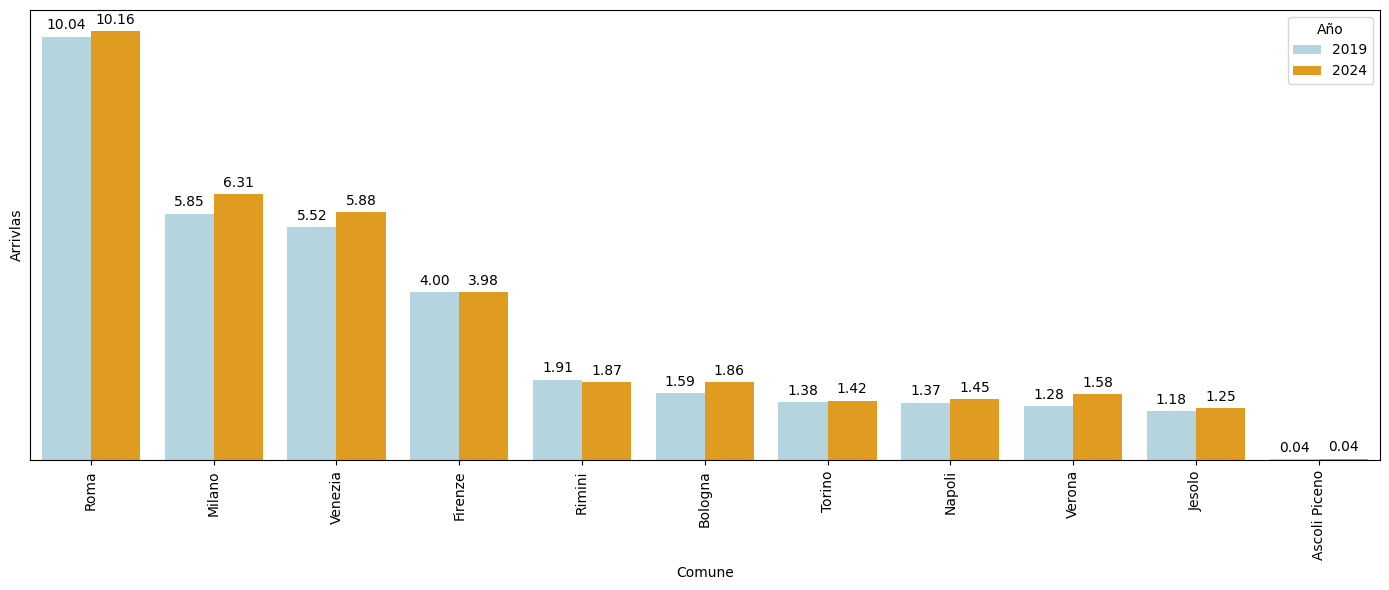

In [21]:
df_filtered = df_final_istat[df_final_istat["Year"].isin([2019, 2024])].copy()

df_2019 = df_filtered[df_filtered["Year"] == 2019]
top10_2019 = df_2019.sort_values("Total Arrivals (All)", ascending=False).head(10)

ascoli = df_filtered[df_filtered["Comune / Municipality"] == "Ascoli Piceno"]
top_comune = pd.concat([top10_2019, ascoli]).drop_duplicates(subset="Comune / Municipality")

final_comune = top_comune["Comune / Municipality"].unique()

df_plot_comp = df_filtered[df_filtered["Comune / Municipality"].isin(final_comune)]

df_plot_comp["Comune / Municipality"] = pd.Categorical(
    df_plot_comp["Comune / Municipality"],
    categories=final_comune,
    ordered=True
)

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=df_plot_comp,
    x="Comune / Municipality",
    y="Total Arrivals (All)",
    hue="Year",
    palette={2019: "lightblue", 2024: "orange"},
    dodge=True
)

# Remove Y axis
ax.set_yticks([])

for container in ax.containers:
    ax.bar_label(
    container,
    labels=[f"{v / 1_000_000:,.2f}" for v in container.datavalues],
    label_type="edge",
    padding=3,
)

#plt.title("Total Arrivals by Comuna (2019 vs 2024)", fontweight="bold")
plt.xlabel("Comune")
plt.ylabel("Arrivlas")
plt.xticks(rotation=90)
plt.legend(title="Año", loc="upper right")
plt.tight_layout()
plt.show()

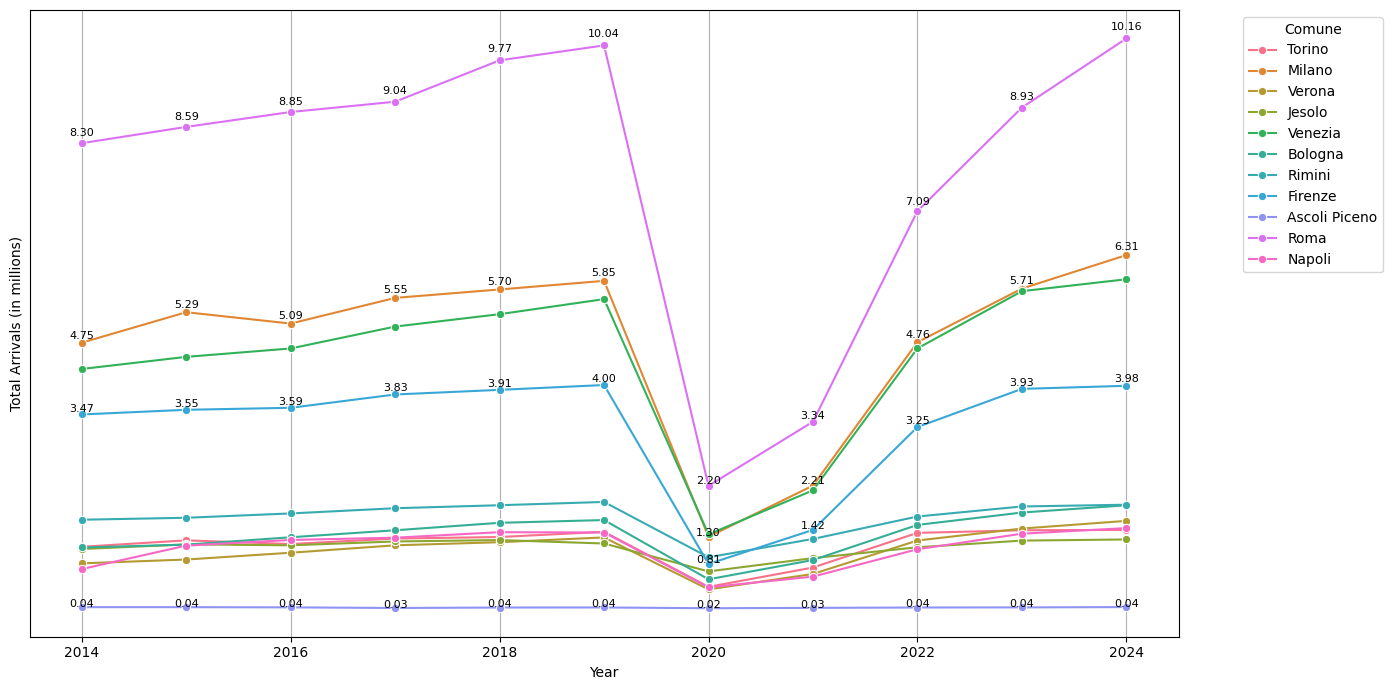

In [22]:
comune = ["Roma", "Milano", "Firenze", "Venezia", "Rimini", "Bologna", "Torino", "Napoli", "Verona", "Jesolo", "Ascoli Piceno"]

evolution = df_final_istat[df_final_istat["Comune / Municipality"].isin(comune)].copy()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=evolution,
    x="Year",
    y="Total Arrivals (All)",
    hue="Comune / Municipality",
    marker="o"
)

comune_etiquetadas = ["Roma", "Milano", "Firenze", "Ascoli Piceno"]

for comune_name in comune:
    df_sub = evolution[evolution["Comune / Municipality"] == comune_name]
    for i, row in df_sub.iterrows():
        year = row["Year"]
        arrivals = row["Total Arrivals (All)"]
        if pd.notnull(arrivals) and comune_name in comune_etiquetadas:
            plt.text(
                x=year,
                y=arrivals + arrivals * 0.015,
                s=f"{arrivals / 1_000_000:,.2f}",
                ha="center",
                fontsize=8,
                color="black"
            )

plt.xlabel("Year")
plt.grid(True)
plt.ylabel("Total Arrivals (in millions)")
plt.yticks([])
plt.legend(title="Comune", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

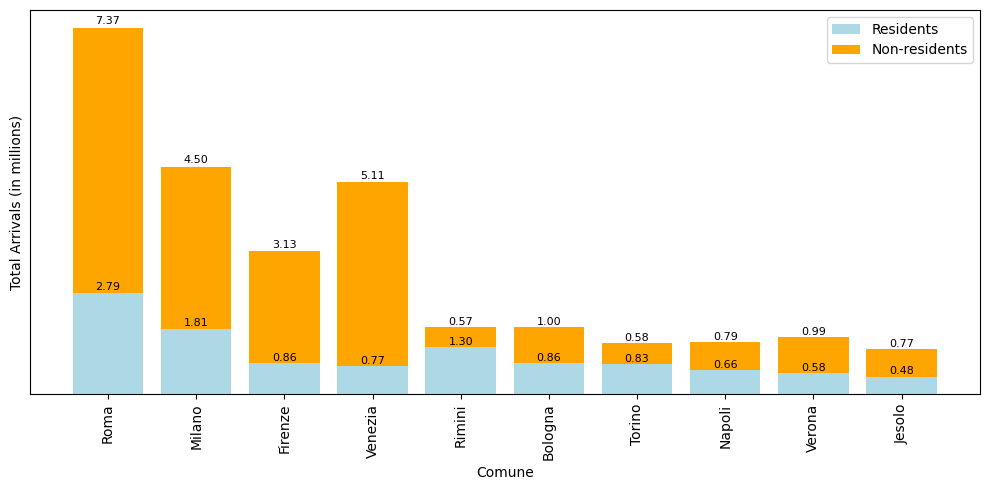

In [23]:
df_2024 = df_final_istat[
    (df_final_istat["Year"] == 2024) & 
    (df_final_istat["Comune / Municipality"].isin(comune))
].copy()

wo_ascoli = [c for c in comune if c != "Ascoli Piceno"]
df_main = df_2024[df_2024["Comune / Municipality"].isin(wo_ascoli)].copy()
df_main["Comune / Municipality"] = pd.Categorical(df_main["Comune / Municipality"], categories=wo_ascoli, ordered=True)
df_main = df_main.sort_values("Comune / Municipality")

residenti = df_main["Total Arrivals (Residents)"]
non_residenti = df_main["Total Arrivals (Non residents)"]
comuni = df_main["Comune / Municipality"]

plt.figure(figsize=(10, 5))
bars1 = plt.bar(comuni, residenti, label="Residents", color="lightblue")
bars2 = plt.bar(comuni, non_residenti, bottom=residenti, label="Non-residents", color="orange")

for bar_r, bar_nr in zip(bars1, bars2):
    h_r = bar_r.get_height()
    h_nr = bar_nr.get_height()
    
    x = bar_r.get_x() + bar_r.get_width() / 2

    plt.text(
        x,
        h_r + h_r * 0.01,
        f"{h_r / 1_000_000:,.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

    plt.text(
        x,
        h_r + h_nr + h_nr * 0.01,
        f"{h_nr / 1_000_000:,.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        color='black'
    )

#plt.title("Total Arrivals by Comune (2024) — Residents vs Non-residents", fontweight="bold")
plt.xlabel("Comune")
plt.ylabel("Total Arrivals (in millions)")
plt.yticks([])
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

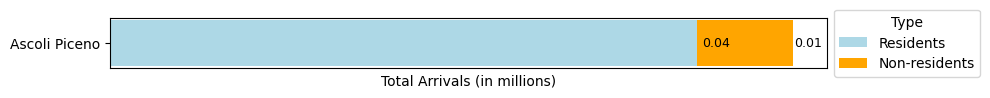

In [24]:
df_ascoli = df_2024[df_2024["Comune / Municipality"] == "Ascoli Piceno"].copy()

residenti = df_ascoli["Total Arrivals (Residents)"].values[0]
non_residenti = df_ascoli["Total Arrivals (Non residents)"].values[0]

plt.figure(figsize=(10, 1))  
bars1 = plt.barh("Ascoli Piceno", residenti, label="Residents", color="lightblue")
bars2 = plt.barh("Ascoli Piceno", non_residenti, left=residenti, label="Non-residents", color="orange")

plt.text(
    residenti + residenti * 0.01,
    0,
    f"{int(residenti)/1_000_000:,.2f}",
    va='center',
    fontsize=9,
    color='black'
)
plt.text(
    residenti + non_residenti + non_residenti * 0.01,
    0,
    f"{int(non_residenti)/1_000_000:,.2f}",
    va='center',
    fontsize=9,
    color='black'
)

plt.xlabel("Total Arrivals (in millions)")
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks([])
plt.tight_layout()
plt.show()